# Prediksi Harga Emas Antam — Hybrid SARIMAX + XGBoost / LightGBM

---
### Pipeline Overview
1. Install & Import Library  
2. Konfigurasi  
3. Load & Merge 5 Dataset  
4. EDA  
5. Uji Stasioneritas (ADF)  
6. Feature Engineering  
7. Train / Test Split (70/30)  
8. SARIMAX Baseline + Walk-Forward Evaluation  
9. Hyperparameter Tuning — XGBoost (Optuna)  
10. Hyperparameter Tuning — LightGBM (Optuna)  
11. Direct Multi-Step Hybrid Forecast (H+1 s.d. H+7)  
12. Evaluasi & Perbandingan Model per Horizon  
13. Visualisasi Hasil  
14. Feature Importance  
15. Simpan Model & Hasil

## Install & Import Library

In [15]:
# install libraryt
!pip install statsmodels yfinance pandas-datareader requests scikit-learn xgboost lightgbm optuna plotly --quiet

In [68]:
# import some libarries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import os
import json
import pickle
import random

import requests
import re
import yfinance as yf
from datetime import datetime

from openpyxl import load_workbook

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb
import lightgbm as lgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [17]:
# set reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed = 42
set_seed(seed)

## Konfigurasi

In [18]:
# path dataset
PATH_ANTAM = '/content/harga_emas_antm.csv'
PATH_XAU = '/content/Data Historis XAU_USD.csv'
PATH_KURS = '/content/data_kurs_usd_idr.xlsx'
PATH_BI = '/content/BI-7Day-RR.xlsx'
PATH_INFLASI = '/content/Data Inflasi.xlsx'

In [19]:
# config crawling, feature engineering params modeling
START_DATE = '2019-01-01'
END_DATE = '2026-02-20'
TRAIN_RATIO = 0.70
MAX_HORIZON = 7
SARIMAX_ORDER = (1, 1, 1)
SARIMAX_SEAS = (0, 0, 0, 0)
N_OPTUNA_TRIALS = 50

## Scraping Data (Antaam & Kurs USD/IDR)

### Emas Antam

Sumber: pusatdata.kontan.co.id

In [20]:
# function scraping emas antam
def scrape_antam(start_date: str, end_date: str) -> pd.DataFrame:
    url = 'https://pusatdata.kontan.co.id/market/chart_logam_mulia/'
    params = {
        'startdate': start_date,
        'enddate': end_date,
        'logam': 'gold'
    }
    headers = {
        'User-Agent': 'Mozilla/5.0',
        'X-Requested-With': 'XMLHttpRequest',
        'Referer': 'https://pusatdata.kontan.co.id/market/logam_mulia'
    }

    res = requests.get(url, params=params, headers=headers, timeout=30)
    res.raise_for_status()

    html = res.text

    # ambil semua tanggal
    tanggal_list = re.findall(r"tanggal\.push\('([^']+)'\)", html)

    # ambil semua harga
    harga_list = re.findall(r"harga\.push\('([^']+)'\)", html)

    if not harga_list:
        harga_list = re.findall(r"(?:price|harga_emas|gold|nilai)\.push\('([^']+)'\)", html)

    print('Jumlah tanggal:', len(tanggal_list))
    print('Jumlah harga  :', len(harga_list))

    if not harga_list:
        with open('debug_chart_logam_mulia.html', 'w', encoding='utf-8') as f:
            f.write(html)
        raise Exception('Data harga tidak ketemu')

    if len(tanggal_list) != len(harga_list):
        print('Warn: jumlah tanggal dan harga beda')
        min_len = min(len(tanggal_list), len(harga_list))
        tanggal_list = tanggal_list[:min_len]
        harga_list = harga_list[:min_len]

    df = pd.DataFrame({
        'tanggal': tanggal_list,
        'nama_logam': 'GOLD',
        'harga': harga_list
    })

    # konsistensi tipe data
    df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')
    df['harga'] = (
        df['harga']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '', regex=False)
    )
    df['harga'] = pd.to_numeric(df['harga'], errors='coerce')

    df = df.dropna(subset=['tanggal', 'harga']).sort_values('tanggal').reset_index(drop=True)

    return df

print('Scraping harga emas antam')
df_antam = scrape_antam(START_DATE, END_DATE)
print(
    f'Berhasil - {len(df_antam)} baris | '
    f'{df_antam['tanggal'].iloc[0].date()} s/d {df_antam['tanggal'].iloc[-1].date()}'
)
df_antam.head()

Scraping harga emas antam
Jumlah tanggal: 2410
Jumlah harga  : 2410
Berhasil - 2410 baris | 2019-01-02 s/d 2026-02-20


,tanggal,nama_logam,harga
0,2019-01-02,GOLD,665000
1,2019-01-03,GOLD,667000
2,2019-01-04,GOLD,672000
3,2019-01-05,GOLD,664000
4,2019-01-07,GOLD,664000


In [21]:
# save ke csv
df_antam.to_csv(PATH_ANTAM, index=False)

### Kurs USD/IDR

In [22]:
# function download data (yahoo finance)
def fetch_yahoo(ticker: str, col_name: str, start: str, end: str) -> pd.DataFrame:
    raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if raw.empty:
        raise Exception(f'Tidak ada data untuk ticker {ticker}')

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    series = raw['Close'].rename(col_name)
    series.index = pd.to_datetime(series.index)
    series.index.name = 'tanggal'
    return series.to_frame()

print('Download kurs USD/IDR')
df_kurs = fetch_yahoo('IDR=X', 'kurs_usdidr', START_DATE, END_DATE)
print(f'USD/IDR — {len(df_kurs)} baris | {df_kurs.index[0].date()} s/d {df_kurs.index[-1].date()}')
df_kurs.head()

Download kurs USD/IDR
USD/IDR — 1857 baris | 2019-01-01 s/d 2026-02-19


,kurs_usdidr
tanggal,
2019-01-01,14460.000000
2019-01-02,14460.000000
2019-01-03,14409.700195
2019-01-04,14375.400391
2019-01-07,14267.000000


In [23]:
# konsistensi data
df_kurs = df_kurs.reset_index()
df_kurs.head()

,tanggal,kurs_usdidr
0,2019-01-01,14460.000000
1,2019-01-02,14460.000000
2,2019-01-03,14409.700195
3,2019-01-04,14375.400391
4,2019-01-07,14267.000000


In [24]:
# save
df_kurs.to_excel(PATH_KURS, index=False)

## Load & Merge Dataset

In [25]:
BULAN_ID = {
    'Januari':'01','Februari':'02','Maret':'03','April':'04',
    'Mei':'05','Juni':'06','Juli':'07','Agustus':'08',
    'September':'09','Oktober':'10','November':'11','Desember':'12'
}

def parse_tgl_id(s):
    p = s.strip().split()
    return pd.to_datetime(f"{p[2]}-{BULAN_ID[p[1]]}-{p[0].zfill(2)}")

def parse_periode_id(s):
    p = s.strip().split()
    return pd.to_datetime(f"{p[1]}-{BULAN_ID[p[0]]}-01")

# 1. Harga Emas Antam
df_antam = pd.read_csv(PATH_ANTAM)
df_antam['tanggal'] = pd.to_datetime(df_antam['tanggal'])
df_antam = df_antam[['tanggal','harga']].rename(columns={'harga':'harga_emas_antam_idr'}).set_index('tanggal').sort_index()

# 2. XAU/USD (Investing.com)
df_xau = pd.read_csv(PATH_XAU)
df_xau['Tanggal'] = pd.to_datetime(df_xau['Tanggal'], format='%d/%m/%Y')
df_xau['harga_emas_dunia_usd'] = (df_xau['Terakhir']
    .str.replace('.','',regex=False).str.replace(',','.',regex=False).astype(float))
df_xau = df_xau[['Tanggal','harga_emas_dunia_usd']].set_index('Tanggal').sort_index()

# 3. Kurs USD/IDR (yfinance)
df_kurs = pd.read_excel(PATH_KURS)
df_kurs.columns = ['tanggal','kurs_usdidr']
df_kurs['tanggal'] = pd.to_datetime(df_kurs['tanggal'])
df_kurs = df_kurs[['tanggal','kurs_usdidr']].set_index('tanggal').sort_index()

# 4. BI 7-Day RR Rate (Bank Indonesia)
wb_bi = load_workbook(PATH_BI, read_only=True); ws_bi = wb_bi.active
bi_rows = []
for row in ws_bi.iter_rows(values_only=True):
    if row[0] is not None and isinstance(row[0], int):
        bi_rows.append({'tanggal': parse_tgl_id(row[1]),
                        'bi_7drr_rate': float(row[2].replace('%','').strip())})
df_bi = pd.DataFrame(bi_rows).set_index('tanggal').sort_index()

# 5. Inflasi YoY (Bank Indonesia)
wb_inf = load_workbook(PATH_INFLASI, read_only=True); ws_inf = wb_inf.active
inf_rows = []
for row in ws_inf.iter_rows(values_only=True):
    if row[0] is not None and isinstance(row[0], int):
        inf_rows.append({'tanggal': parse_periode_id(row[1]),
                         'inflasi_yoy_id': float(row[2].replace('%','').strip())})
df_inflasi = pd.DataFrame(inf_rows).set_index('tanggal').sort_index()

In [31]:
# merge ke daily index
full_idx = pd.date_range(start=START_DATE, end=END_DATE, freq='D')

df = pd.DataFrame(index=full_idx)
df.index.name = 'tanggal' # set index

# join seluruh data
df = df.join(df_antam).join(df_xau).join(df_kurs)
df = df.join(df_bi.reindex(full_idx).ffill().bfill())
df = df.join(df_inflasi.reindex(full_idx).ffill().bfill())
df = df.ffill().bfill() # fillna metode (ffill dan bfill)

# filter hari kerja (Senin–Jumat) (oposional)
# df = df[df.index.dayofweek < 5].copy()

## Data Understanding

In [27]:
df.head()

,harga_emas_antam_idr,harga_emas_dunia_usd,kurs_usdidr,bi_7drr_rate,inflasi_yoy_id
tanggal,,,,,
2019-01-01,665000.0,1282.62,14460.000000,6.0,2.82
2019-01-02,665000.0,1284.77,14460.000000,6.0,2.82
2019-01-03,667000.0,1293.99,14409.700195,6.0,2.82
2019-01-04,672000.0,1284.92,14375.400391,6.0,2.82
2019-01-05,664000.0,1284.92,14375.400391,6.0,2.82


In [28]:
# cek shape
print(f'Shape: {df.shape}')

# cek periode
print(f'Periode : {df.index[0].date()} s/d {df.index[-1].date()}')

Shape: (2608, 5)
Periode : 2019-01-01 s/d 2026-02-20


In [29]:
# cek missing values
print(f'Missing :\n{df.isnull().sum()}')

Missing :
harga_emas_antam_idr    0
harga_emas_dunia_usd    0
kurs_usdidr             0
bi_7drr_rate            0
inflasi_yoy_id          0
dtype: int64


In [30]:
# descriptive stats
df.describe(
    include='all'
).T

,count,mean,std,min,25%,50%,75%,max
harga_emas_antam_idr,2608.0,1.168408e+06,466945.519079,655500.000000,930000.000000,997500.000,1.327000e+06,3.168000e+06
harga_emas_dunia_usd,2608.0,2.130911e+03,753.868275,1270.540000,1735.925000,1876.765,2.328340e+03,5.400250e+03
kurs_usdidr,2608.0,1.508745e+04,889.550587,13213.240234,14300.224854,14897.000,1.578893e+04,1.705190e+04
bi_7drr_rate,2608.0,4.943252e+00,1.003896,3.500000,3.750000,5.000,5.812500e+00,6.250000e+00
inflasi_yoy_id,2608.0,2.703834e+00,1.218753,-0.090000,1.680000,2.610,3.280000e+00,5.950000e+00


In [78]:
# save data static
static_df = df[['harga_emas_dunia_usd', 'inflasi_yoy_id', 'bi_7drr_rate']].copy()

static_df = static_df.rename(columns={
    'harga_emas_dunia_usd': 'xau_usd'
})

static_df = static_df.reset_index()
static_df.rename(columns={'tanggal': 'date'}, inplace=True)

static_df.to_csv('master_static.csv', index=False)

## 3. Exploratory Data Analysis (EDA)

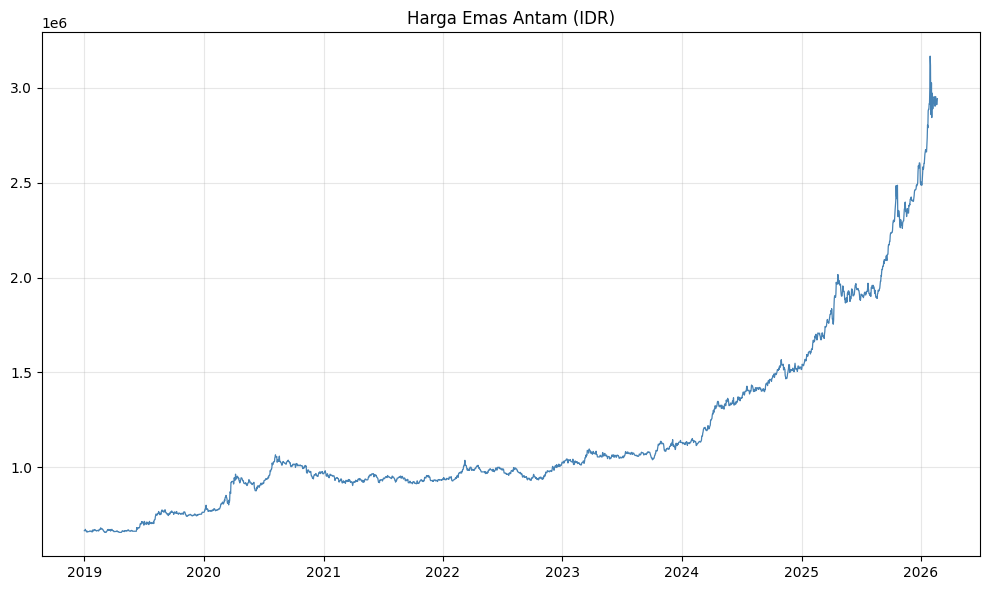

In [33]:
# visualisasi emas antam
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, df['harga_emas_antam_idr'], linewidth=0.9, color='steelblue')
ax.set_title('Harga Emas Antam (IDR)');
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

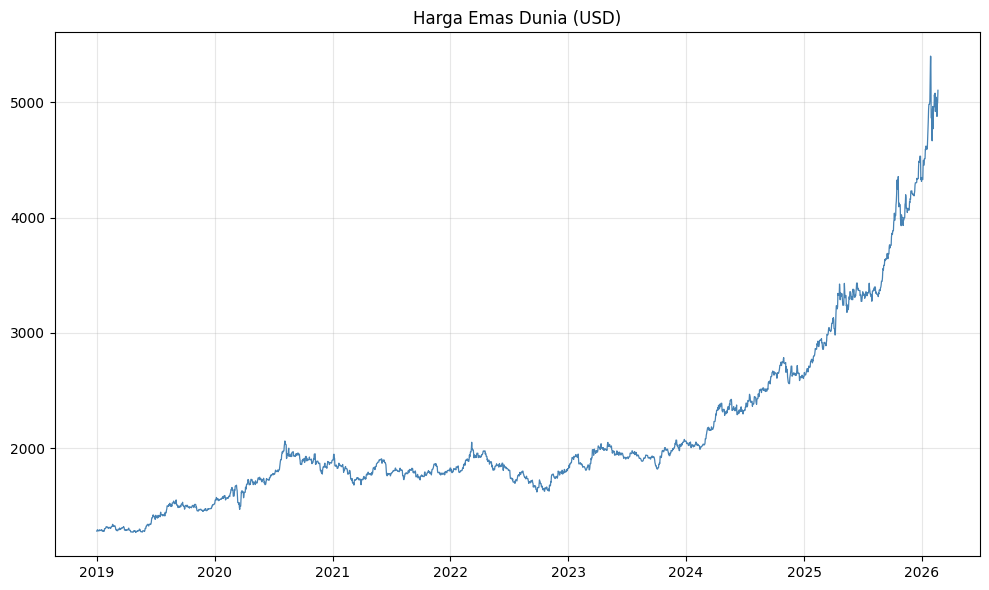

In [34]:
# visualisasi emas dunia
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, df['harga_emas_dunia_usd'], linewidth=0.9, color='steelblue')
ax.set_title('Harga Emas Dunia (USD)');
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

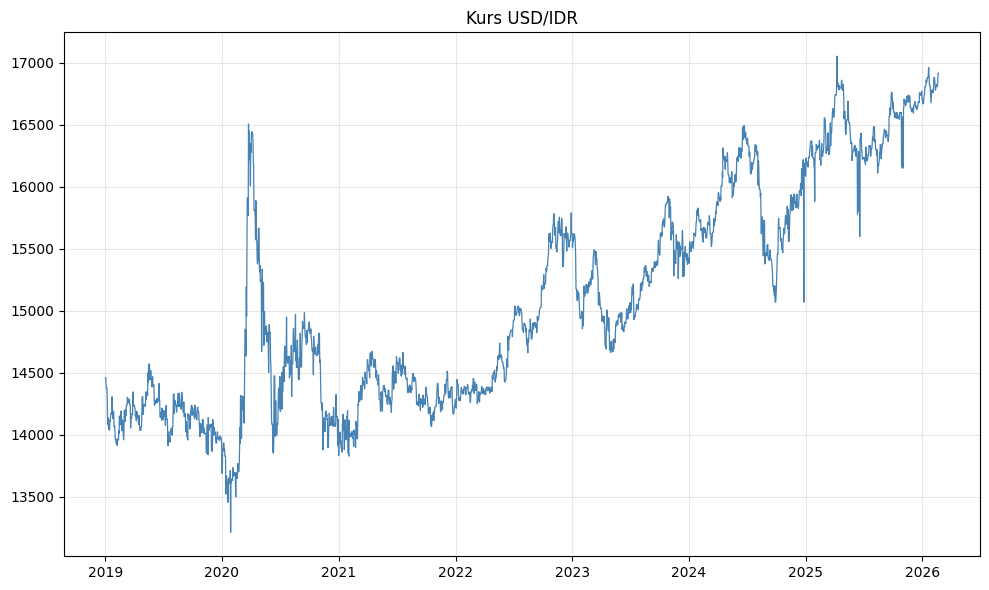

In [35]:
# visualisasi kurs usd/idr
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, df['kurs_usdidr'], linewidth=0.9, color='steelblue')
ax.set_title('Kurs USD/IDR');
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

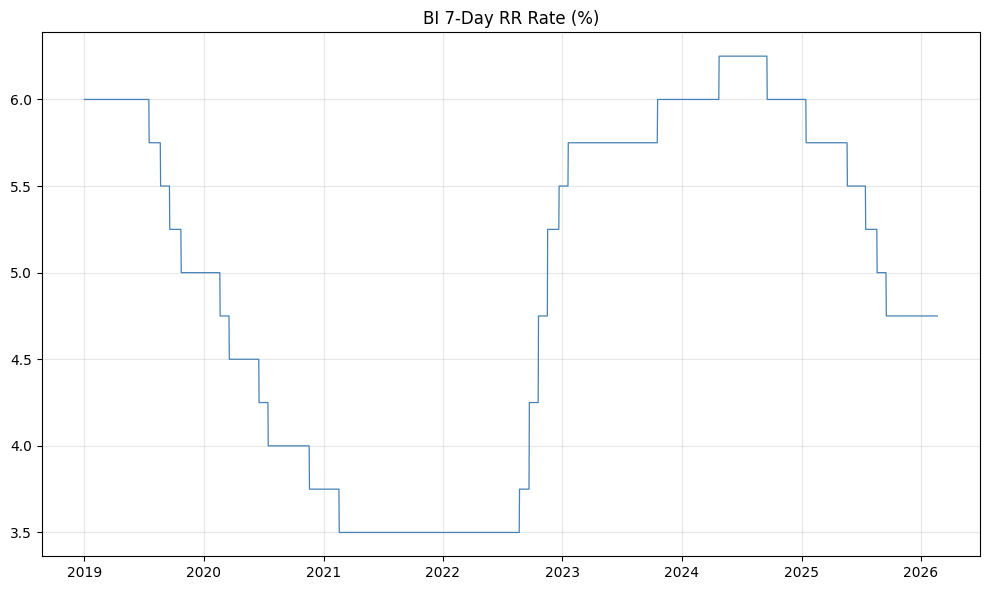

In [36]:
# visualisasi birate
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, df['bi_7drr_rate'], linewidth=0.9, color='steelblue')
ax.set_title('BI 7-Day RR Rate (%)');
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

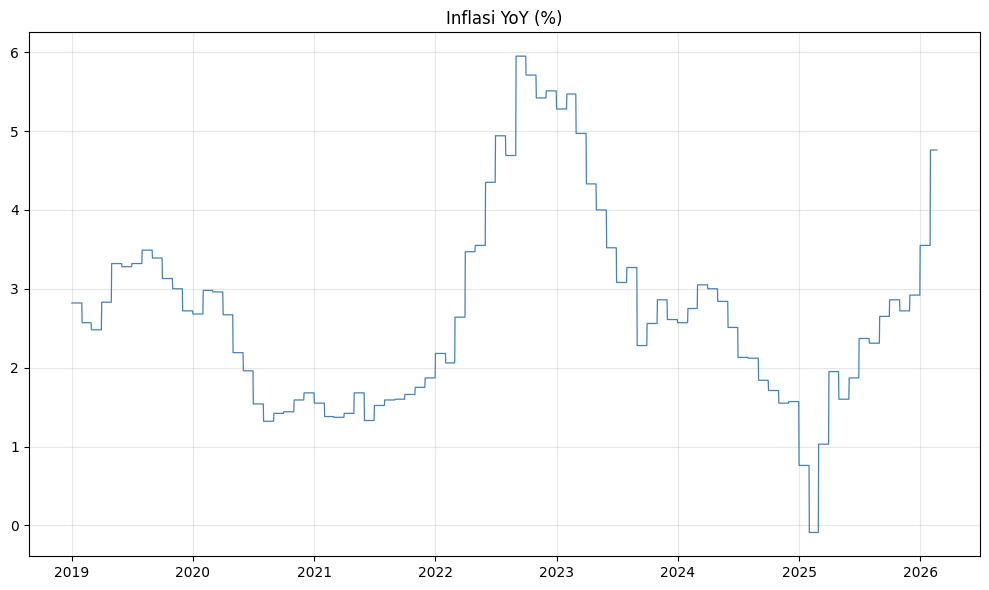

In [37]:
# visualisasi inflasi
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, df['inflasi_yoy_id'], linewidth=0.9, color='steelblue')
ax.set_title('Inflasi YoY (%)');
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Uji Stasioneritas (ADF Test)

In [39]:
# function adf test (cek stasioner)
def adf_test(series, name):
    res = adfuller(series.dropna(), autolag='AIC')
    status = 'Stasioner' if res[1] < 0.05 else 'Tidak Stasioner'
    print(f'{name:<35} | ADF: {res[0]:>8.4f} | p: {res[1]:.4f} | {status}')

print('Level:')
adf_test(df['harga_emas_antam_idr'], 'Harga Emas Antam (level)')
adf_test(df['harga_emas_dunia_usd'], 'Harga Emas Dunia (level)')
adf_test(df['kurs_usdidr'], 'Kurs USD/IDR (level)')

df['log_harga'] = np.log(df['harga_emas_antam_idr'])
df['log_xau'] = np.log(df['harga_emas_dunia_usd'])
df['log_kurs'] = np.log(df['kurs_usdidr'])

print('\nLog')
adf_test(df['log_harga'], 'log(Harga Emas Antam)')
adf_test(df['log_xau'], 'log(Harga Emas Dunia)')
adf_test(df['log_kurs'], 'log(Kurs USD/IDR)')

print('\nLog First Difference')
adf_test(df['log_harga'].diff().dropna(), 'log(Harga Emas Antam)')
adf_test(df['log_xau'].diff().dropna(), 'log(Harga Emas Dunia)')
adf_test(df['log_kurs'].diff().dropna(), 'log(Kurs USD/IDR)')

Level:
Harga Emas Antam (level)            | ADF:   5.0517 | p: 1.0000 | Tidak Stasioner
Harga Emas Dunia (level)            | ADF:   5.6124 | p: 1.0000 | Tidak Stasioner
Kurs USD/IDR (level)                | ADF:  -1.6036 | p: 0.4818 | Tidak Stasioner

Log
log(Harga Emas Antam)               | ADF:   2.5870 | p: 0.9991 | Tidak Stasioner
log(Harga Emas Dunia)               | ADF:   2.3568 | p: 0.9990 | Tidak Stasioner
log(Kurs USD/IDR)                   | ADF:  -1.6935 | p: 0.4345 | Tidak Stasioner

Log First Difference
log(Harga Emas Antam)               | ADF: -14.7073 | p: 0.0000 | Stasioner
log(Harga Emas Dunia)               | ADF: -17.2375 | p: 0.0000 | Stasioner
log(Kurs USD/IDR)                   | ADF:  -8.9902 | p: 0.0000 | Stasioner


## Feature Engineering

In [40]:
# Log return
df['log_return'] = df['log_harga'].diff()

# Lag features
for lag in [1, 2, 3, 5, 7]:
    df[f'lag_{lag}'] = df['log_harga'].shift(lag)

# Rolling statistics (berbasis t-1 untuk hindari data leakage)
df['rolling_mean_7']  = df['log_harga'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['log_harga'].shift(1).rolling(7).std()
df['rolling_mean_14'] = df['log_harga'].shift(1).rolling(14).mean()
df['rolling_std_14'] = df['log_harga'].shift(1).rolling(14).std()

# Kalender
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter

# Spread makro (BI Rate - Inflasi)
df['spread_macro'] = df['bi_7drr_rate'] - df['inflasi_yoy_id']

# Lag eksogen
df['log_xau_lag1'] = df['log_xau'].shift(1)
df['log_kurs_lag1'] = df['log_kurs'].shift(1)

# drop data kosong jika ada
df = df.dropna().copy()

In [41]:
# fitur yg diambil
FEATURE_COLS = [
    'log_return',
    'lag_1','lag_2','lag_3','lag_5','lag_7',
    'rolling_mean_7','rolling_std_7','rolling_mean_14','rolling_std_14',
    'log_xau','log_kurs','log_xau_lag1','log_kurs_lag1',
    'bi_7drr_rate','inflasi_yoy_id','spread_macro',
    'day_of_week','month','quarter'
]

EXOG_SARIMAX = ['log_xau', 'log_kurs']  # eksogen SARIMAX: XAU/USD & Kurs saja

print(f'Shape setelah feature engineering: {df.shape}')
print(f'SARIMAX exogenous : {EXOG_SARIMAX}')
print(f'Boosting features : {len(FEATURE_COLS)} kolom')
df[FEATURE_COLS].head()

Shape setelah feature engineering: (2594, 24)
SARIMAX exogenous : ['log_xau', 'log_kurs']
Boosting features : 20 kolom


,log_return,lag_1,lag_2,lag_3,lag_5,lag_7,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,log_xau,log_kurs,log_xau_lag1,log_kurs_lag1,bi_7drr_rate,inflasi_yoy_id,spread_macro,day_of_week,month,quarter
tanggal,,,,,,,,,,,,,,,,,,,,
2019-01-15,0.000000,13.399995,13.399995,13.399995,13.403021,13.399995,13.399777,0.002220,13.404299,0.005751,7.161862,9.555135,7.163738,9.549523,6.0,2.82,3.18,1,1,1
2019-01-16,0.001514,13.399995,13.399995,13.399995,13.399995,13.395439,13.399777,0.002220,13.403760,0.005777,7.165122,9.554710,7.161862,9.555135,6.0,2.82,3.18,2,1,1
2019-01-17,0.003021,13.401509,13.399995,13.399995,13.399995,13.403021,13.400644,0.001190,13.403329,0.005698,7.163869,9.556763,7.165122,9.554710,6.0,2.82,3.18,3,1,1
2019-01-18,0.000000,13.404530,13.401509,13.399995,13.399995,13.399995,13.400859,0.001714,13.402900,0.005327,7.155779,9.559094,7.163869,9.556763,6.0,2.82,3.18,4,1,1
2019-01-19,0.000000,13.404530,13.404530,13.401509,13.399995,13.399995,13.401507,0.002138,13.401937,0.003163,7.155779,9.559094,7.155779,9.559094,6.0,2.82,3.18,5,1,1


## Train / Test Split (70% / 30%)

In [42]:
# splitting data
split_idx = int(len(df) * TRAIN_RATIO)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

print(f'Train : {len(train):>5} baris | {train.index[0].date()} – {train.index[-1].date()}')
print(f'Test : {len(test):>5} baris | {test.index[0].date()} – {test.index[-1].date()}')

Train :  1815 baris | 2019-01-15 – 2024-01-03
Test :   779 baris | 2024-01-04 – 2026-02-20


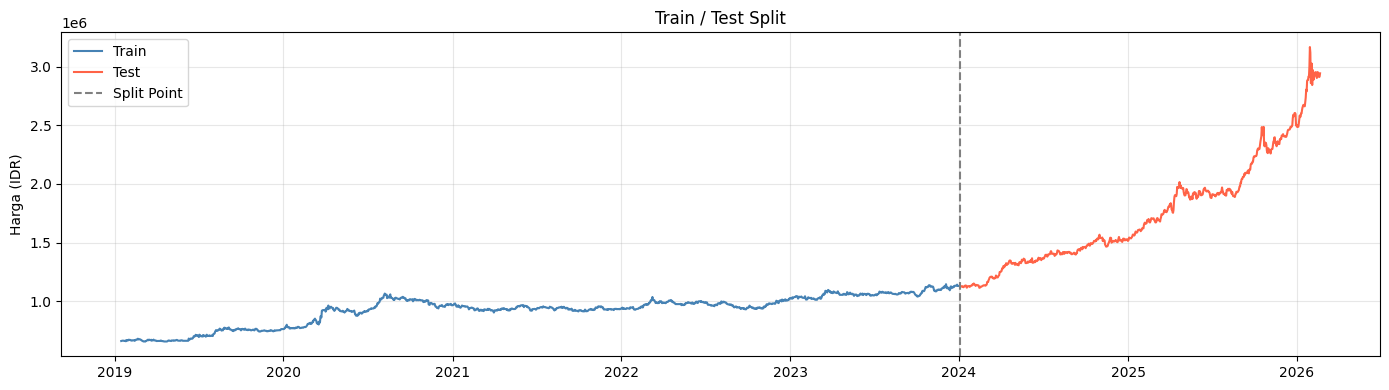

In [43]:
# visualisasi
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(train.index, train['harga_emas_antam_idr'], label='Train', color='steelblue')
ax.plot(test.index,  test['harga_emas_antam_idr'],  label='Test',  color='tomato')
ax.axvline(train.index[-1], color='gray', linestyle='--', label='Split Point')
ax.set_title('Train / Test Split')
ax.set_ylabel('Harga (IDR)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model SARIMAX (Baseline)

**Eksogen SARIMAX:** `log_xau` (harga emas dunia) dan `log_kurs` (kurs USD/IDR) saja.  
Inflasi & BI Rate digunakan pada tahap boosting sebagai fitur tambahan.

In [45]:
# fitting model srammax
print(f'Fitting SARIMAX{SARIMAX_ORDER} x {SARIMAX_SEAS}')

sarimax_fit = SARIMAX(
    train['log_harga'],
    exog=train[EXOG_SARIMAX],
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEAS,
    enforce_stationarity=False,
    enforce_invertibility=False,
    freq='D'
).fit(disp=False, maxiter=300)

print(f'AIC : {sarimax_fit.aic:.2f}')
print(f'BIC : {sarimax_fit.bic:.2f}')
print(sarimax_fit.summary().tables[1])

Fitting SARIMAX(1, 1, 1) x (0, 0, 0, 0)
AIC : -13243.03
BIC : -13215.52
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
log_xau        0.0459      0.014      3.185      0.001       0.018       0.074
log_kurs      -0.0685      0.016     -4.159      0.000      -0.101      -0.036
ar.L1          0.0861      0.180      0.479      0.632      -0.266       0.438
ma.L1         -0.1915      0.179     -1.067      0.286      -0.543       0.160
sigma2      3.895e-05      6e-07     64.948      0.000    3.78e-05    4.01e-05


In [46]:
# Residual in-sample untuk boosting
train['residual'] = train['log_harga'].values - sarimax_fit.fittedvalues.values
print(f'\nResidual in-sample — mean: {train['residual'].mean():.6f} | std: {train['residual'].std():.6f}')


Residual in-sample — mean: 0.007562 | std: 0.322531


### SARIMAX Walk-Forward Evaluation (H+1)

In [49]:
# copy residual sebelumnya
history_wf = train.copy()
sarimax_preds_1step = []

# training loop
for i in range(len(test)):
    m = SARIMAX(
        history_wf['log_harga'], exog=history_wf[EXOG_SARIMAX],
        order=SARIMAX_ORDER, seasonal_order=SARIMAX_SEAS,
        enforce_stationarity=False, enforce_invertibility=False, freq='D'
    ).fit(disp=False, maxiter=200)

    fc = m.forecast(steps=1, exog=test[EXOG_SARIMAX].iloc[[i]])
    sarimax_preds_1step.append(fc.values[0])
    history_wf = pd.concat([history_wf, test.iloc[[i]]])

test['sarimax_pred_log'] = sarimax_preds_1step
test['sarimax_pred'] = np.exp(test['sarimax_pred_log'])

# eval
mae_s = mean_absolute_error(test['harga_emas_antam_idr'], test['sarimax_pred'])
rmse_s = np.sqrt(mean_squared_error(test['harga_emas_antam_idr'], test['sarimax_pred']))
r2_s = r2_score(test['harga_emas_antam_idr'], test['sarimax_pred'])

print(f'\nSARIMAX H+1 (Walk-Forward)')
print(f'MAE : {mae_s:>12,.2f}')
print(f'RMSE: {rmse_s:>12,.2f}')
print(f'R² : {r2_s:>12.4f}')


SARIMAX H+1 (Walk-Forward)
MAE :    11,318.16
RMSE:    22,175.71
R² :       0.9977


## Hyperparameter Tuning - XGBoost (Optuna)

In [50]:
tscv = TimeSeriesSplit(n_splits=5)

# tuning dasar pada residual 1-step
X_train = train[FEATURE_COLS].values
y_train = train['residual'].values

def objective_xgb(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 100, 500),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth' : trial.suggest_int('max_depth', 3, 8),
        'subsample' : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha' : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda' : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'random_state': seed,
        'n_jobs': -1,
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X_train):
        m = xgb.XGBRegressor(**params)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[va_idx], y_train[va_idx])], verbose=False)
        scores.append(mean_squared_error(y_train[va_idx], m.predict(X_train[va_idx])))
    return np.mean(scores)

study_xgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=seed))
study_xgb.optimize(objective_xgb, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_xgb_params = {**study_xgb.best_params, 'random_state': seed, 'n_jobs': -1}
print(f'\nBest XGBoost params: {best_xgb_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost params: {'n_estimators': 393, 'learning_rate': 0.01462677783233291, 'max_depth': 5, 'subsample': 0.6733770981851532, 'colsample_bytree': 0.6229229260629712, 'reg_alpha': 9.635570193444867, 'reg_lambda': 2.0102616957639583, 'random_state': 42, 'n_jobs': -1}


## Hyperparameter Tuning - LightGBM (Optuna)

In [51]:
def objective_lgb(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 100, 500),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth' : trial.suggest_int('max_depth', 3, 8),
        'num_leaves' : trial.suggest_int('num_leaves', 20, 100),
        'subsample' : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha' : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda' : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'random_state': seed,
        'n_jobs' : -1,
        'verbose' : -1,
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X_train):
        m = lgb.LGBMRegressor(**params) # lgbm
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[va_idx], y_train[va_idx])],
              callbacks=[lgb.early_stopping(20, verbose=False),
                         lgb.log_evaluation(period=-1)])
        scores.append(mean_squared_error(y_train[va_idx], m.predict(X_train[va_idx])))
    return np.mean(scores)

study_lgb = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=seed))
study_lgb.optimize(objective_lgb, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_lgb_params = {**study_lgb.best_params,
                   'random_state': seed, 'n_jobs': -1, 'verbose': -1}

print(f'\nBest LightGBM params: {best_lgb_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best LightGBM params: {'n_estimators': 208, 'learning_rate': 0.29809911697393254, 'max_depth': 7, 'num_leaves': 71, 'subsample': 0.7045301052546397, 'colsample_bytree': 0.6037244622276555, 'reg_alpha': 0.022055966549515135, 'reg_lambda': 0.18340281663501548, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


## Direct Multi-Step Hybrid Forecast (H+1 s.d. H+7)

In [52]:
# training loop & eval loop
# function evaluate
def evaluate_forecast(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred)
    }

all_results = []
metrics_rows = []

for h in range(1, MAX_HORIZON + 1):
    print(f'--- Horizon H+{h} ---')

    # residual_h = actual_{t+h} - forecast_sarimax_{t->t+h} pada data training
    train_pairs = []

    for t in range(len(train) - h):
        history_y = train['log_harga'].iloc[:t+1]
        history_exog = train[EXOG_SARIMAX].iloc[:t+1]
        future_exog = train[EXOG_SARIMAX].iloc[t+1:t+1+h]

        if len(future_exog) < h:
            continue

        try:
            m_hist = SARIMAX(
                history_y,
                exog=history_exog,
                order=SARIMAX_ORDER,
                seasonal_order=SARIMAX_SEAS,
                enforce_stationarity=False,
                enforce_invertibility=False,
                freq='D'
            ).fit(disp=False, maxiter=200)

            fc_h = m_hist.forecast(steps=h, exog=future_exog).iloc[-1]
            actual_log_h = train['log_harga'].iloc[t + h]
            residual_h = actual_log_h - fc_h

            feature_row = train[FEATURE_COLS].iloc[t]
            train_pairs.append((feature_row.values, residual_h))

        except Exception:
            continue

    X_tr = np.array([p[0] for p in train_pairs])
    y_tr = np.array([p[1] for p in train_pairs])

    print(f'Training samples untuk residual H+{h}: {len(X_tr)}')

    # Train residual models
    xgb_h = xgb.XGBRegressor(**best_xgb_params)
    xgb_h.fit(X_tr, y_tr)

    lgb_h = lgb.LGBMRegressor(**best_lgb_params)
    lgb_h.fit(X_tr, y_tr)

    # Walk-forward forecast pada test set
    history_wf = train.copy()

    sarimax_preds_log = []
    actual_vals = []
    feat_rows = []

    for i in range(len(test) - h + 1):
        exog_future = test[EXOG_SARIMAX].iloc[i:i+h]
        if len(exog_future) < h:
            break

        try:
            m = SARIMAX(
                history_wf['log_harga'],
                exog=history_wf[EXOG_SARIMAX],
                order=SARIMAX_ORDER,
                seasonal_order=SARIMAX_SEAS,
                enforce_stationarity=False,
                enforce_invertibility=False,
                freq='D'
            ).fit(disp=False, maxiter=200)

            fc = m.forecast(steps=h, exog=exog_future)
            sarimax_log_h = fc.iloc[-1]

            sarimax_preds_log.append(sarimax_log_h)
            feat_rows.append(test[FEATURE_COLS].iloc[i].values)
            actual_vals.append(test['harga_emas_antam_idr'].iloc[i + h - 1])

            # update history
            history_wf = pd.concat([history_wf, test.iloc[[i]]])

        except Exception:
            continue

    sarimax_preds_log = np.array(sarimax_preds_log)
    X_feat = np.array(feat_rows)
    actual_arr = np.array(actual_vals)

    # Prediksi residual + combine hybrid
    xgb_resid_h = xgb_h.predict(X_feat)
    lgb_resid_h = lgb_h.predict(X_feat)

    pred_sarimax = np.exp(sarimax_preds_log)
    pred_xgb = np.exp(sarimax_preds_log + xgb_resid_h)
    pred_lgb = np.exp(sarimax_preds_log + lgb_resid_h)

    # eval
    res_s = evaluate_forecast(actual_arr, pred_sarimax)
    res_xgb = evaluate_forecast(actual_arr, pred_xgb)
    res_lgb = evaluate_forecast(actual_arr, pred_lgb)

    all_results.append({
        'horizon': h,
        'actual': actual_arr,
        'sarimax_preds': pred_sarimax,
        'xgb_preds': pred_xgb,
        'lgb_preds': pred_lgb,
        'sarimax': res_s,
        'hybrid_xgb': res_xgb,
        'hybrid_lgb': res_lgb,
        'xgb_model': xgb_h,
        'lgb_model': lgb_h,
    })

    metrics_rows.extend([
        {'horizon': f'H+{h}', 'model': 'SARIMAX', 'MAE': res_s['mae'], 'RMSE': res_s['rmse'], 'R2': res_s['r2']},
        {'horizon': f'H+{h}', 'model': 'Hybrid SARIMAX-XGBoost', 'MAE': res_xgb['mae'], 'RMSE': res_xgb['rmse'], 'R2': res_xgb['r2']},
        {'horizon': f'H+{h}', 'model': 'Hybrid SARIMAX-LightGBM', 'MAE': res_lgb['mae'], 'RMSE': res_lgb['rmse'], 'R2': res_lgb['r2']},
    ])

    print(
        f'H+{h} | '
        f'SARIMAX MAE: {res_s['mae']:>10,.0f} R²:{res_s['r2']:>7.3f} | '
        f'XGB MAE: {res_xgb['mae']:>10,.0f} R²:{res_xgb['r2']:>7.3f} | '
        f'LGB MAE: {res_lgb['mae']:>10,.0f} R²:{res_lgb['r2']:>7.3f}'
    )

print('\nDirect Multi-Step Hybrid selesai')

--- Horizon H+1 ---
Training samples untuk residual H+1: 1813
H+1 | SARIMAX MAE:     11,318 R²:  0.998 | XGB MAE:     11,260 R²:  0.998 | LGB MAE:     10,837 R²:  0.998
--- Horizon H+2 ---
Training samples untuk residual H+2: 1812
H+2 | SARIMAX MAE:     16,074 R²:  0.996 | XGB MAE:     15,876 R²:  0.996 | LGB MAE:     20,019 R²:  0.995
--- Horizon H+3 ---
Training samples untuk residual H+3: 1811
H+3 | SARIMAX MAE:     19,926 R²:  0.995 | XGB MAE:     19,588 R²:  0.995 | LGB MAE:     29,332 R²:  0.992
--- Horizon H+4 ---
Training samples untuk residual H+4: 1810
H+4 | SARIMAX MAE:     23,575 R²:  0.994 | XGB MAE:     23,044 R²:  0.994 | LGB MAE:     31,994 R²:  0.991
--- Horizon H+5 ---
Training samples untuk residual H+5: 1809
H+5 | SARIMAX MAE:     26,491 R²:  0.993 | XGB MAE:     25,815 R²:  0.993 | LGB MAE:     35,668 R²:  0.989
--- Horizon H+6 ---
Training samples untuk residual H+6: 1808
H+6 | SARIMAX MAE:     29,418 R²:  0.991 | XGB MAE:     28,555 R²:  0.992 | LGB MAE:     45,3

## Evaluasi & Perbandingan Model per Horizon

In [53]:
# tabel hasil evaluasi semmua horizon
results_df = pd.DataFrame(metrics_rows)
results_df = results_df.sort_values(['horizon', 'model']).reset_index(drop=True)
results_df

,horizon,model,MAE,RMSE,R2
0,H+1,Hybrid SARIMAX-LightGBM,10837.446693,21550.431341,0.997851
1,H+1,Hybrid SARIMAX-XGBoost,11260.068926,22116.190833,0.997737
2,H+1,SARIMAX,11318.159839,22175.714237,0.997725
3,H+2,Hybrid SARIMAX-LightGBM,20019.149249,31878.579459,0.995293
4,H+2,Hybrid SARIMAX-XGBoost,15875.696917,28083.948594,0.996347
5,H+2,SARIMAX,16074.284045,28243.284288,0.996306
6,H+3,Hybrid SARIMAX-LightGBM,29332.054951,40657.222222,0.992336
7,H+3,Hybrid SARIMAX-XGBoost,19588.040308,31202.734456,0.995486
8,H+3,SARIMAX,19925.525453,31517.778897,0.995394
9,H+4,Hybrid SARIMAX-LightGBM,31994.342297,44798.624004,0.990686


In [54]:
# ringkasan model terbaik
best_per_horizon = results_df.loc[results_df.groupby('horizon')['RMSE'].idxmin()].reset_index(drop=True)
print('Model terbaik per horizon berdasarkan RMSE:')
best_per_horizon

Model terbaik per horizon berdasarkan RMSE:


,horizon,model,MAE,RMSE,R2
0,H+1,Hybrid SARIMAX-LightGBM,10837.446693,21550.431341,0.997851
1,H+2,Hybrid SARIMAX-XGBoost,15875.696917,28083.948594,0.996347
2,H+3,Hybrid SARIMAX-XGBoost,19588.040308,31202.734456,0.995486
3,H+4,Hybrid SARIMAX-XGBoost,23043.509235,35514.731769,0.994146
4,H+5,Hybrid SARIMAX-XGBoost,25815.308168,39129.501356,0.992887
5,H+6,Hybrid SARIMAX-XGBoost,28555.049578,42418.355385,0.991632
6,H+7,Hybrid SARIMAX-XGBoost,30796.488365,46231.255584,0.990050


## Visualisasi Hasil Prediksi

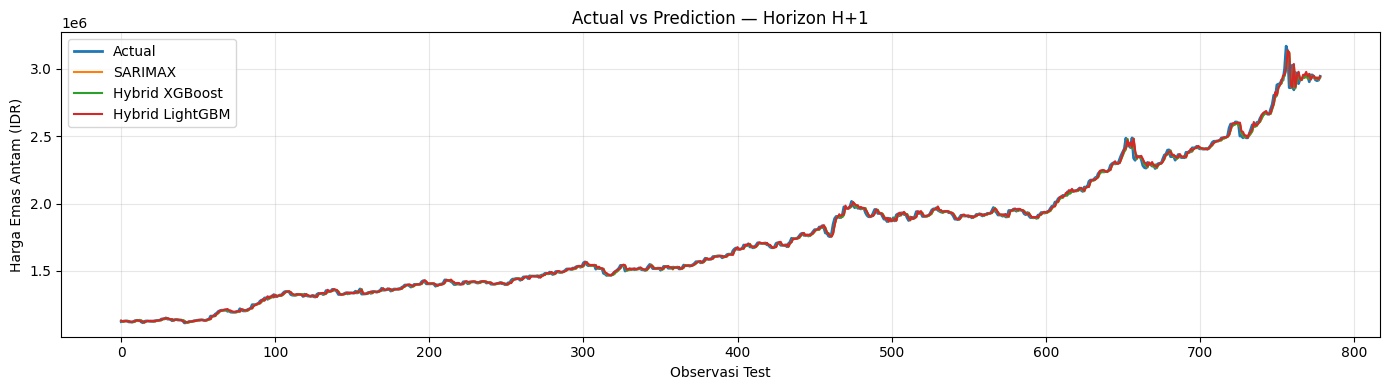

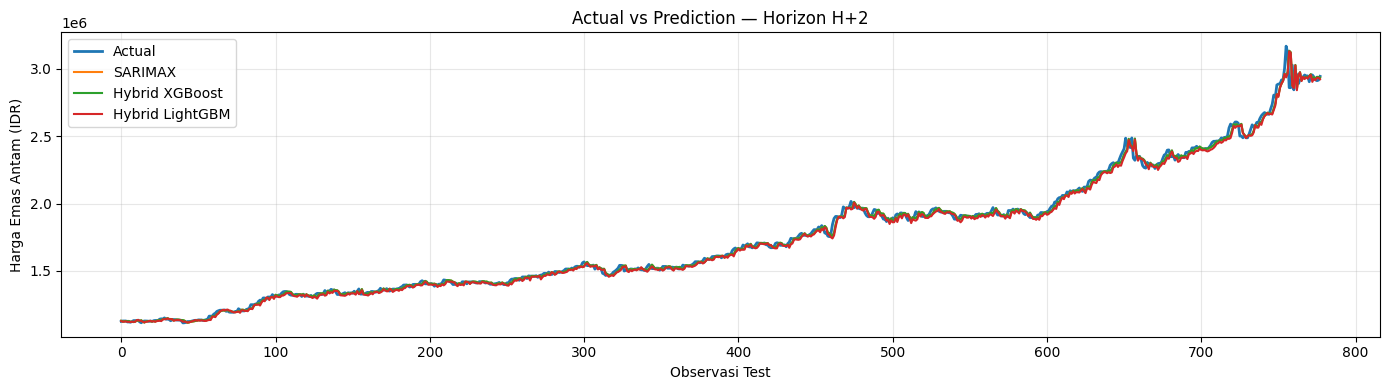

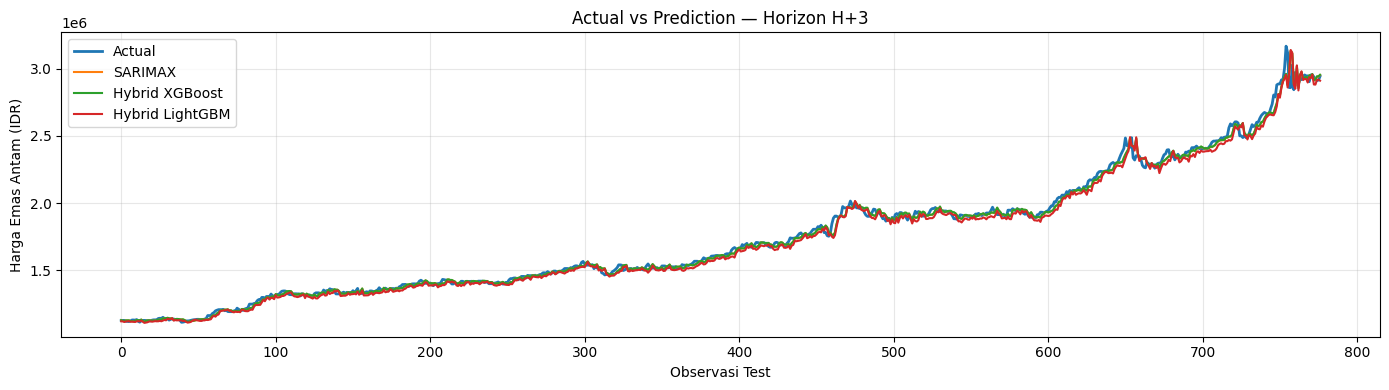

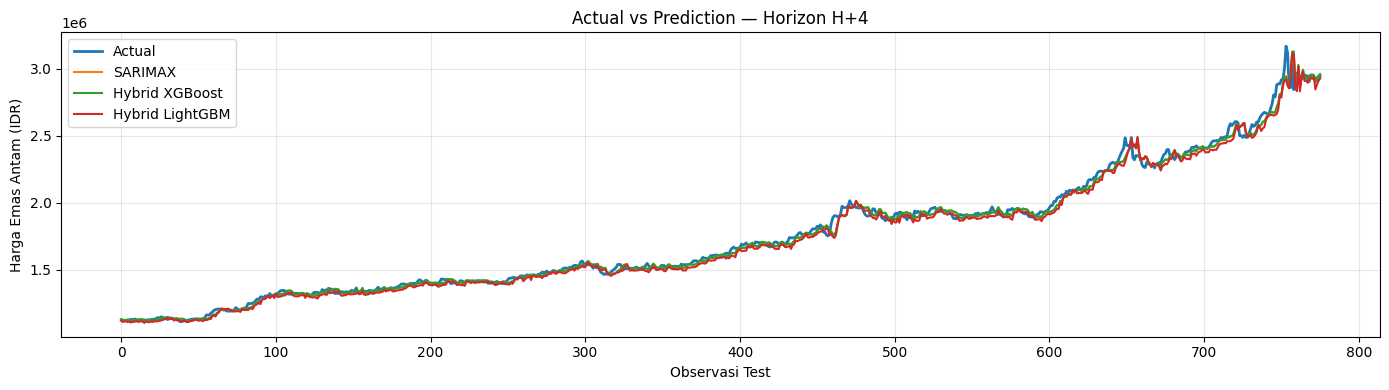

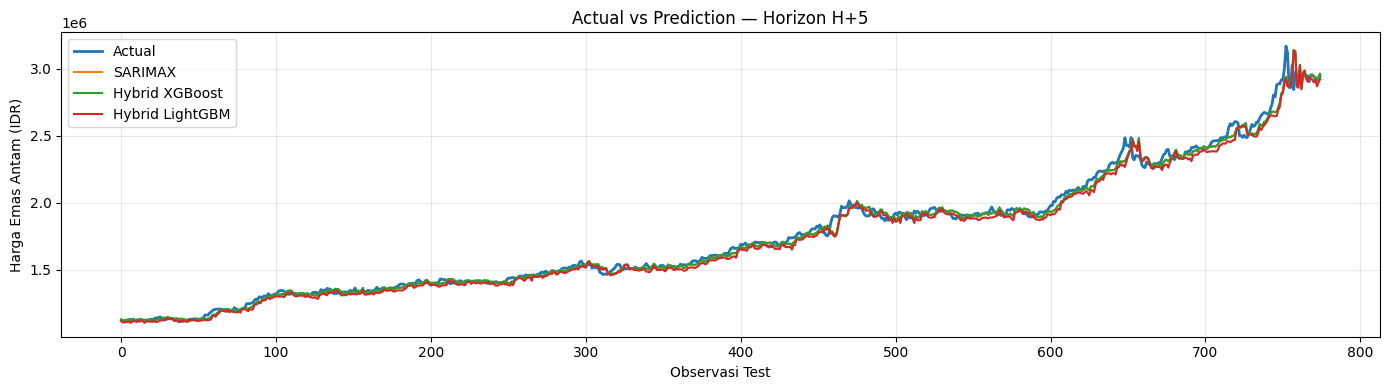

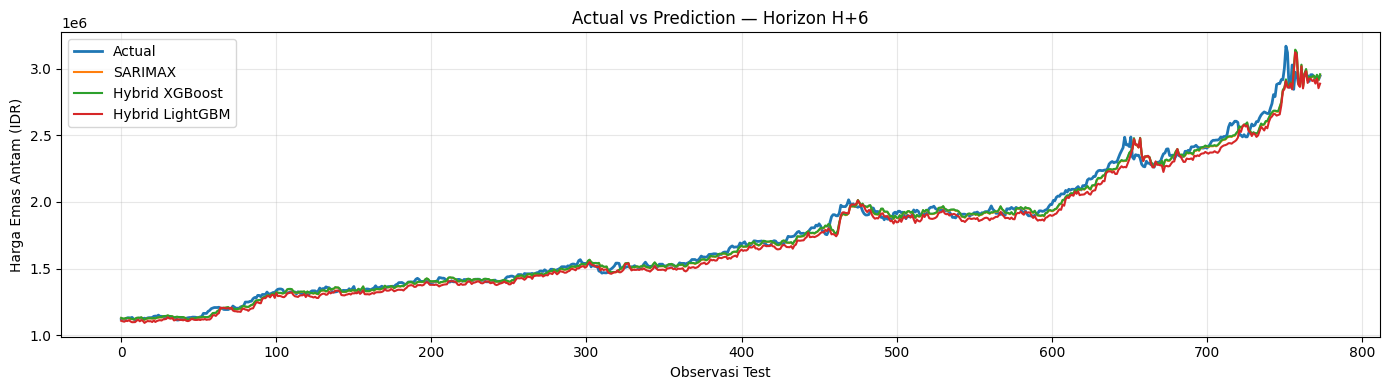

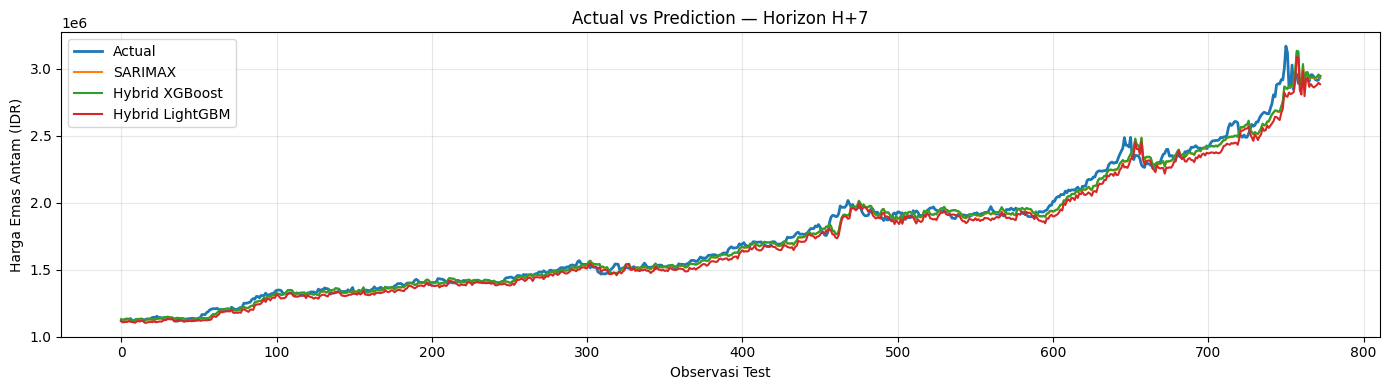

In [56]:
# visualisasi actual vs predicted horizn
for res in all_results:
    h = res['horizon']

    plt.figure(figsize=(14, 4))
    plt.plot(res['actual'], label='Actual', linewidth=2)
    plt.plot(res['sarimax_preds'], label='SARIMAX')
    plt.plot(res['xgb_preds'], label='Hybrid XGBoost')
    plt.plot(res['lgb_preds'], label='Hybrid LightGBM')
    plt.title(f'Actual vs Prediction — Horizon H+{h}')
    plt.ylabel('Harga Emas Antam (IDR)')
    plt.xlabel('Observasi Test')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Feature Importance

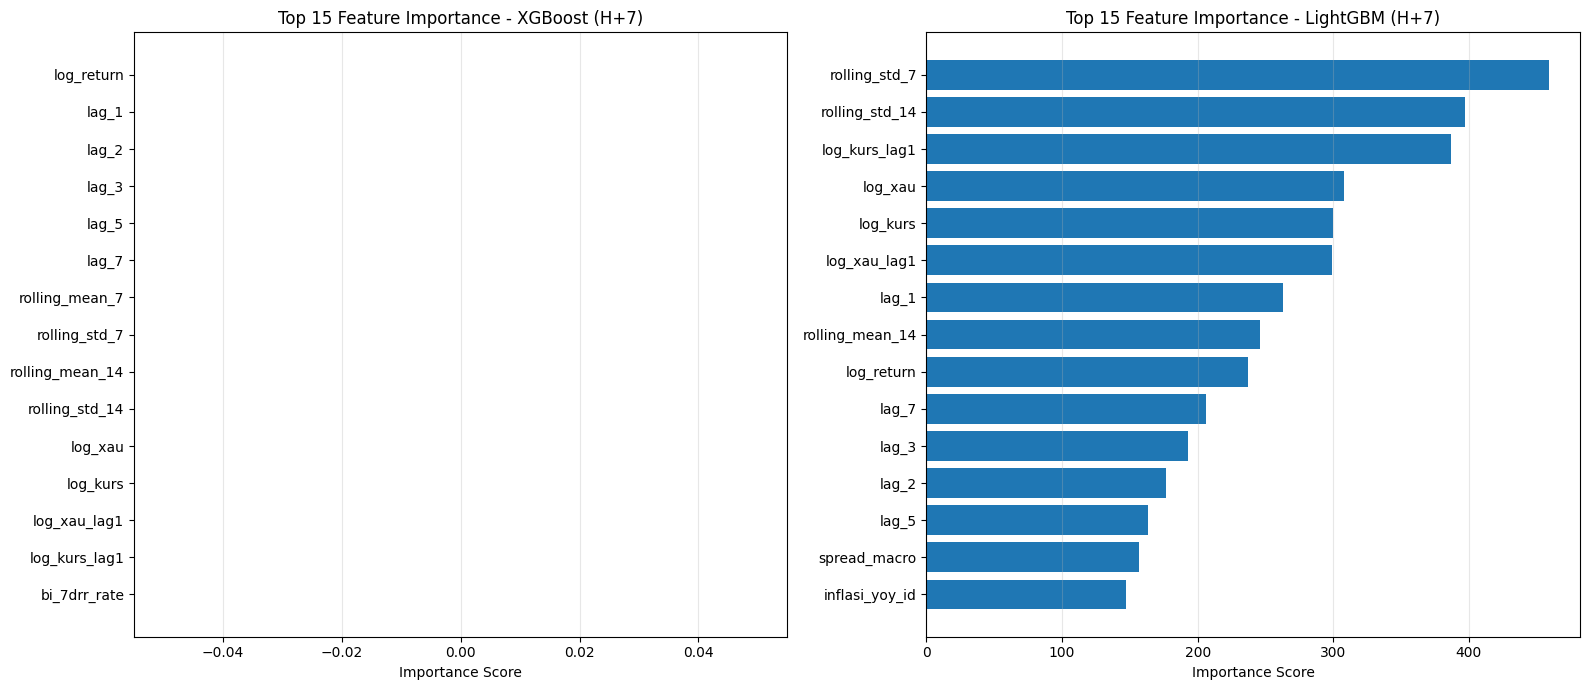

In [65]:
# feature importance (model/hoorizon terakhir)
last_res = all_results[-1]
xgb_model_last = last_res['xgb_model']
lgb_model_last = last_res['lgb_model']

# XGBoost importance
xgb_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': xgb_model_last.feature_importances_
}).sort_values('importance', ascending=False)

# LightGBM importance
lgb_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': lgb_model_last.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(xgb_imp['feature'].head(15)[::-1], xgb_imp['importance'].head(15)[::-1])
axes[0].set_title('Top 15 Feature Importance - XGBoost (H+' + str(last_res['horizon']) + ')')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(lgb_imp['feature'].head(15)[::-1], lgb_imp['importance'].head(15)[::-1])
axes[1].set_title('Top 15 Feature Importance - LightGBM (H+' + str(last_res['horizon']) + ')')
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

mari kita cek params dari xgb kenapa kok bisa kosong semua feature importacenyta

In [66]:
# cek params xgb
best_xgb_params

{'n_estimators': 393,
 'learning_rate': 0.01462677783233291,
 'max_depth': 5,
 'subsample': 0.6733770981851532,
 'colsample_bytree': 0.6229229260629712,
 'reg_alpha': 9.635570193444867,
 'reg_lambda': 2.0102616957639583,
 'random_state': 42,
 'n_jobs': -1}

Berdasarkan hasil hyperparameter tuning menggunakan optuna, diperoleh parameter optimal untuk model XGBoost, di antaranya learning rate sebesar 0.0146, regularisasi L1 (reg_alpha) sebesar 9.6356, dan regularisasi L2 (reg_lambda) sebesar 2.0103.

Nilai regularisasi yang relatif tinggi menunjukkan bahwa model cenderung bersifat konservatif dan menghindari kompleksitas yang berlebihan. Selain itu, nilai learning rate yang kecil mengindikasikan proses pembelajaran yang bertahap dan hati-hati dalam menyesuaikan residual.

Konfigurasi parameter tersebut berdampak pada terbatasnya pembentukan split pada model XGBoost, sehingga feature importance yang dihasilkan menadji mendekati nol. Hal ini menunjukkan bahwa tidak terdapat pola tambahan yang signifikan pada residual yang dapat dimodelkan lebih lanjut oleh XGBoost.

In [67]:
# skrng cek lgbm param
best_lgb_params

{'n_estimators': 208,
 'learning_rate': 0.29809911697393254,
 'max_depth': 7,
 'num_leaves': 71,
 'subsample': 0.7045301052546397,
 'colsample_bytree': 0.6037244622276555,
 'reg_alpha': 0.022055966549515135,
 'reg_lambda': 0.18340281663501548,
 'random_state': 42,
 'n_jobs': -1,
 'verbose': -1}

Bisa dilihat output dioatas, LightGBM menghasilkan learning rate yang lebih besar dan regularisasi (reg_alpha dan reg_lambda) yang jauh lebih rendah. Kondisi ini membuat LightGBM lebih mampu menangkap pola residual yang masih tersisa setelah pemodelan SARIMAX, sehingga feature importance tetap muncul.

## Save Model & Hasil

In [70]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [72]:
# buat folder moodels
os.makedirs('/content/drive/MyDrive/models_forecasting_hybrid', exist_ok=True)

# sv SARIMAX
sarimax_fit.save('/content/drive/MyDrive/models_forecasting_hybrid/sarimax_fit.pkl')

# sv XGBoost & LightGBM per horizon
for r in all_results:
    h = r['horizon']
    with open(f'/content/drive/MyDrive/models_forecasting_hybrid/xgb_h{h}.pkl', 'wb') as f:
        pickle.dump(r['xgb_model'], f)
    with open(f'/content/drive/MyDrive/models_forecasting_hybrid/lgb_h{h}.pkl', 'wb') as f:
        pickle.dump(r['lgb_model'], f)

# sv config
config = {
    'target_col': 'log_harga',
    'original_target_col': 'harga_emas_antam_idr',
    'feature_cols': FEATURE_COLS,
    'exog_sarimax': EXOG_SARIMAX,
    'sarimax_order': list(SARIMAX_ORDER),
    'sarimax_seasonal_order': list(SARIMAX_SEAS),
    'best_xgb_params': best_xgb_params,
    'best_lgb_params': best_lgb_params,
    'train_end_date': str(train.index[-1].date()),
    'max_horizon': MAX_HORIZON,
    'train_ratio': TRAIN_RATIO,
    'lags_used': [1, 2, 3, 5, 7],
    'rolling_windows': [7, 14],
    'frequency': 'D',
    'use_log_return': True
}

with open('/content/drive/MyDrive/models_forecasting_hybrid/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# sv metrik evaluasi
results_df.to_csv('/content/drive/MyDrive/models_forecasting_hybrid/metrics_all_horizons.csv', index=False)
best_per_horizon.to_csv('/content/drive/MyDrive/models_forecasting_hybrid/best_model_per_horizon.csv', index=False)